In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Initial Data Loading
Loading the synthetic financial dataset and inspecting the first few rows to understand the structure.

In [22]:
df = pd.read_csv("data/Synthetic_Financial_datasets_log.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### Data Dimensionality
Checking the shape of the dataframe to understand the total count of transactions.

In [23]:
df.shape

(6362620, 11)

### Data Info and Types
Reviewing data types and memory usage. Note that 'type', 'nameOrig', and 'nameDest' are identified as strings.

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


### Descriptive Statistics
Generating statistical summaries to identify potential outliers and the scale of the transaction amounts.

In [25]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


### Missing Values Check
Verifying data integrity. Confirming there are no missing entries in the dataset.

In [26]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

### Class Imbalance Analysis
Calculating the percentage of fraudulent transactions. This confirms the dataset is highly imbalanced.

In [27]:
df.isFraud.value_counts() / len(df) * 100

isFraud
0    99.870918
1     0.129082
Name: count, dtype: float64

### Feature Engineering and Cleanup
Removing columns that lead to data leakage (balances) or contain high-cardinality IDs (names) to ensure the model generalizes well.

In [28]:
df = df.drop(['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'nameOrig' , 'nameDest'],axis=1)
df.head()

,step,type,amount,isFraud
0,1,PAYMENT,9839.64,0
1,1,PAYMENT,1864.28,0
2,1,TRANSFER,181.00,1
3,1,CASH_OUT,181.00,1
4,1,PAYMENT,11668.14,0


### Sampling for Visualization
Taking a random sample of 100,000 rows for efficient plotting without sacrificing statistical representation.

In [32]:
df_sample = df.sample(n=100000, random_state=42)

### Transaction Amount Distribution
Using a log scale to visualize the distribution of amounts, revealing a bimodal structure.

Text(0.5, 1.0, 'Distribution of Transaction Amounts (Log Scale)')

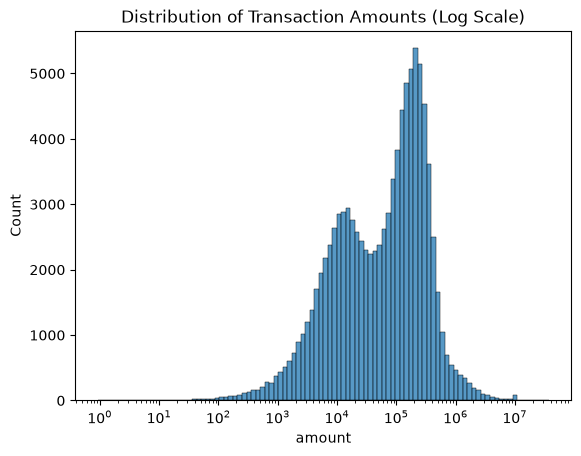

In [33]:
sns.histplot(data=df_sample, x='amount', bins=100, log_scale=True)
plt.title('Distribution of Transaction Amounts (Log Scale)')

The different peaks likely correspond to different types of activity (e.g., ATM withdrawals vs. peer-to-peer transfers). Since fraud often hides in specific value ranges, this bimodal structure suggests that a model might need to treat these two 'clusters' differently. It confirms that simple linear models might struggle, and that tree-based models (like XGBoost or LightGBM) would be better at capturing these non-linear thresholds.

### Investigating Fraud Distribution
Visualizing the distribution specifically for fraudulent transactions, which exposes a concentration at the high-value end.  This suggests that "Amount" is an incredibly high-signal feature for your model.

Text(0.5, 1.0, 'Distribution of Fraudulent Transaction Amounts')

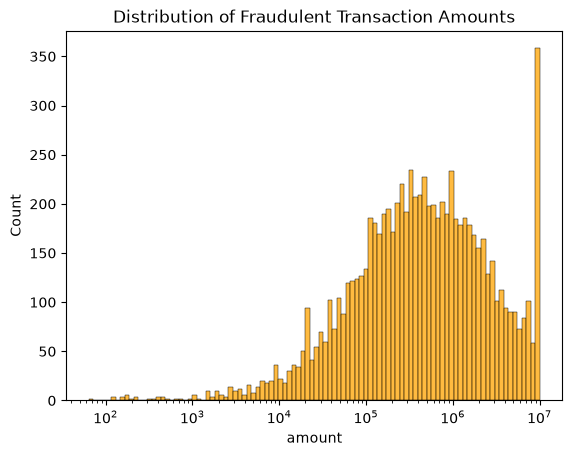

In [38]:
sns.histplot(data=df[df['isFraud'] == 1], x='amount', bins=100, log_scale=True, color='orange')
plt.title('Distribution of Fraudulent Transaction Amounts')

### Fraud Analysis by Transaction Type
Grouping by 'type' to calculate the proportion of fraudulent versus legitimate transactions. This will help determine if fraud is concentrated in specific categories, which is essential for feature importance.

In [45]:
fraud_by_type = df.groupby('type')['isFraud'].value_counts(normalize=True).unstack()
fraud_by_type = fraud_by_type.fillna(0)
fraud_by_type

isFraud,0,1
type,,
CASH_IN,1.000000,0.000000
CASH_OUT,0.998160,0.001840
DEBIT,1.000000,0.000000
PAYMENT,1.000000,0.000000
TRANSFER,0.992312,0.007688
